# Synthetic Weather Data Analysis

## 1. Project objective

The objective of this notebook is to generate and analyze synthetic weather station data as part of the **Smart Weather Station AI Lab** project.

This project is designed to practice Python for data analysis using a realistic sensor-data workflow. The synthetic dataset simulates measurements from a weather station, including:

- Temperature
- Humidity
- Atmospheric pressure
- Ambient light

The goal is to build a clean and reproducible data analysis pipeline that can later be extended with real sensor data, anomaly detection and Machine Learning models.


## 2. Imports

We import the main libraries used for data generation, data manipulation and visualization.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 3. Synthetic data generation

In this section, we generate synthetic weather data for 7 days with hourly measurements.

The generated variables are:

- `timestamp`: date and time of each measurement
- `temperature_c`: temperature in degrees Celsius
- `humidity_percent`: relative humidity in percentage
- `pressure_hpa`: atmospheric pressure in hectopascals
- `light_lux`: ambient light level in lux

The data includes daily patterns and random noise to make it more realistic.

In [18]:
np.random.seed(42)

num_samples = 24 * 7  # 7 days of hourly data
hours = np.arange(num_samples)

timestamps = pd.date_range(
    start="2026-01-01 00:00:00",
    periods=num_samples,
    freq="h"
)

temperature_c = (
    18
    + 6 * np.sin(2 * np.pi * hours / 24)
    + np.random.normal(0, 1.0, num_samples)
)

humidity_percent = (
    65
    - 10 * np.sin(2 * np.pi * hours / 24)
    + np.random.normal(0, 4.0, num_samples)
)

pressure_hpa = (
    1013
    + 3 * np.sin(2 * np.pi * hours / (24 * 3))
    + np.random.normal(0, 1.5, num_samples)
)

light_lux = (
    np.maximum(0, 800 * np.sin(2 * np.pi * (hours - 6) / 24))
    + np.random.normal(0, 30, num_samples)
)

light_lux = np.clip(light_lux, 0, None)

In [19]:
weather_df_generated = pd.DataFrame(
    {
        "timestamp": timestamps,
        "temperature_c": temperature_c,
        "humidity_percent": humidity_percent,
        "pressure_hpa": pressure_hpa,
        "light_lux": light_lux,
    }
)

weather_df_generated.head()

,timestamp,temperature_c,humidity_percent,pressure_hpa,light_lux
0,2026-01-01 00:00:00,18.496714,64.018448,1011.761754,0.000000
1,2026-01-01 01:00:00,19.414650,59.396865,1012.779388,0.000000
2,2026-01-01 02:00:00,21.647689,56.441942,1014.140342,0.000000
3,2026-01-01 03:00:00,23.765671,54.665691,1012.930870,0.000000
4,2026-01-01 04:00:00,22.961999,56.031339,1012.792730,1.455649


## 4. Save dataset to CSV

The generated dataset is saved as a CSV file inside the `data/raw/` folder.

This simulates a realistic workflow where raw sensor data is stored before being analyzed.

In [20]:
DATA_RAW_PATH = Path("../data/raw")
OUTPUT_FILE = DATA_RAW_PATH / "synthetic_weather_data.csv"

DATA_RAW_PATH.mkdir(parents=True, exist_ok=True)

weather_df_generated.to_csv(OUTPUT_FILE, index=False)

print(f"Dataset saved to: {OUTPUT_FILE}")

Dataset saved to: ..\data\raw\synthetic_weather_data.csv


## 5. Load dataset with pandas

We now load the saved CSV file using pandas.

Although the dataset was generated in this notebook, loading it again from disk helps simulate a real-world workflow where data is collected, stored and later analyzed.

In [21]:
weather_df = pd.read_csv(OUTPUT_FILE)

weather_df.head()

,timestamp,temperature_c,humidity_percent,pressure_hpa,light_lux
0,2026-01-01 00:00:00,18.496714,64.018448,1011.761754,0.000000
1,2026-01-01 01:00:00,19.414650,59.396865,1012.779388,0.000000
2,2026-01-01 02:00:00,21.647689,56.441942,1014.140342,0.000000
3,2026-01-01 03:00:00,23.765671,54.665691,1012.930870,0.000000
4,2026-01-01 04:00:00,22.961999,56.031339,1012.792730,1.455649


In [22]:
weather_df["timestamp"] = pd.to_datetime(weather_df["timestamp"])

weather_df.head()

,timestamp,temperature_c,humidity_percent,pressure_hpa,light_lux
0,2026-01-01 00:00:00,18.496714,64.018448,1011.761754,0.000000
1,2026-01-01 01:00:00,19.414650,59.396865,1012.779388,0.000000
2,2026-01-01 02:00:00,21.647689,56.441942,1014.140342,0.000000
3,2026-01-01 03:00:00,23.765671,54.665691,1012.930870,0.000000
4,2026-01-01 04:00:00,22.961999,56.031339,1012.792730,1.455649


## 6. Data inspection

Before analyzing the data, we inspect its structure, column types and possible missing values.

In [23]:
weather_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         168 non-null    datetime64[us]
 1   temperature_c     168 non-null    float64       
 2   humidity_percent  168 non-null    float64       
 3   pressure_hpa      168 non-null    float64       
 4   light_lux         168 non-null    float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 6.7 KB


In [24]:
weather_df.isnull().sum()

timestamp           0
temperature_c       0
humidity_percent    0
pressure_hpa        0
light_lux           0
dtype: int64

In [25]:
weather_df.shape

(168, 5)

The dataset contains 168 rows and 5 columns, representing 7 days of hourly weather measurements.

## 7. Basic statistics

We calculate descriptive statistics to understand the general behavior of each sensor variable.

In [26]:
weather_df.describe()

,timestamp,temperature_c,humidity_percent,pressure_hpa,light_lux
count,168,168.000000,168.000000,168.000000,168.000000
mean,2026-01-04 11:30:00,17.960887,65.301906,1013.292853,258.179939
min,2026-01-01 00:00:00,10.792141,47.871681,1007.425798,0.000000
25%,2026-01-02 17:45:00,13.657954,58.551213,1011.180173,0.000000
50%,2026-01-04 11:30:00,18.249756,65.058824,1013.306001,42.894463
75%,2026-01-06 05:15:00,22.368400,72.000688,1015.288339,556.851987
max,2026-01-07 23:00:00,25.986011,90.070184,1018.761902,836.036418
std,NaN,4.353754,8.272985,2.706026,304.714878


In [27]:
basic_stats = weather_df[
    ["temperature_c", "humidity_percent", "pressure_hpa", "light_lux"]
].agg(["mean", "min", "max", "std"])

basic_stats

,temperature_c,humidity_percent,pressure_hpa,light_lux
mean,17.960887,65.301906,1013.292853,258.179939
min,10.792141,47.871681,1007.425798,0.000000
max,25.986011,90.070184,1018.761902,836.036418
std,4.353754,8.272985,2.706026,304.714878


## 8. Visualizations

We visualize the synthetic weather variables to identify daily patterns, trends and relationships between signals.

### 8.1 Temperature over time

Temperature follows a daily cycle, increasing and decreasing over each 24-hour period.

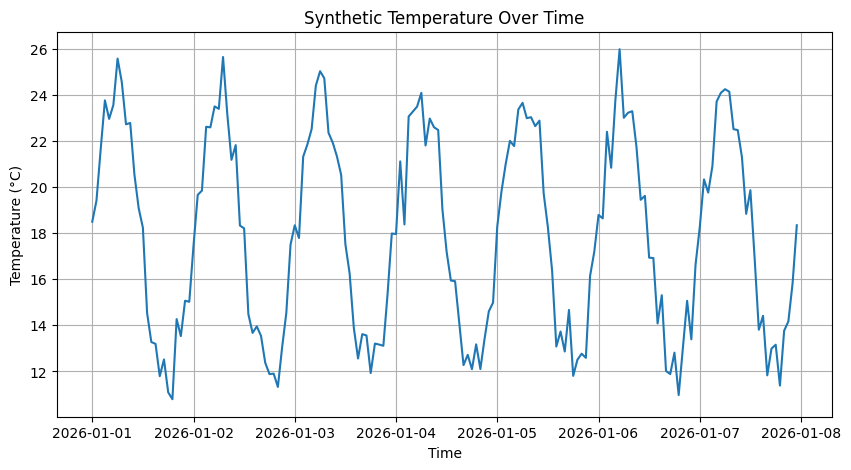

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(weather_df["timestamp"], weather_df["temperature_c"])
plt.title("Synthetic Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

### 8.2 Humidity over time

Humidity follows an inverse pattern compared to temperature.

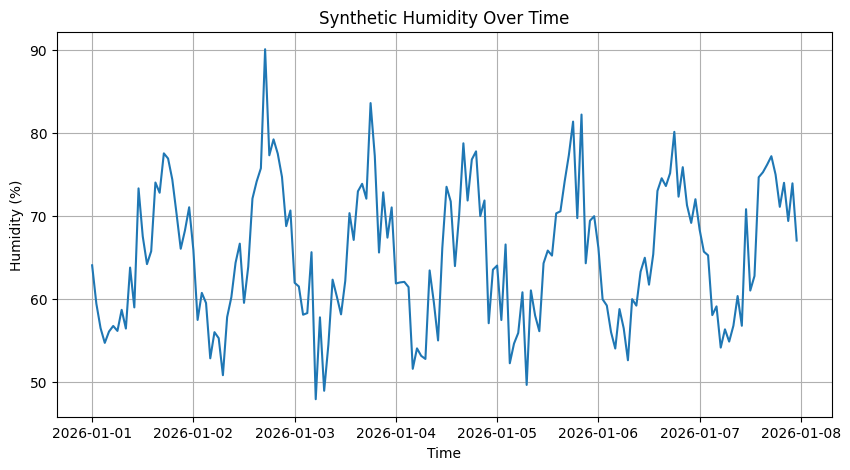

In [29]:
plt.figure(figsize=(10, 5))
plt.plot(weather_df["timestamp"], weather_df["humidity_percent"])
plt.title("Synthetic Humidity Over Time")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.grid(True)
plt.show()

### 8.3 Atmospheric pressure over time

Pressure changes more slowly than temperature and humidity.

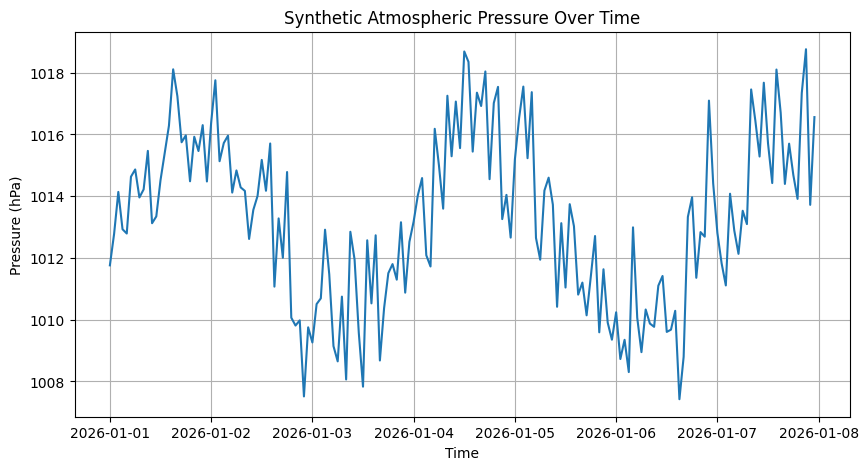

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(weather_df["timestamp"], weather_df["pressure_hpa"])
plt.title("Synthetic Atmospheric Pressure Over Time")
plt.xlabel("Time")
plt.ylabel("Pressure (hPa)")
plt.grid(True)
plt.show()

### 8.4 Ambient light over time

Light intensity is close to zero during the night and increases during daylight hours.

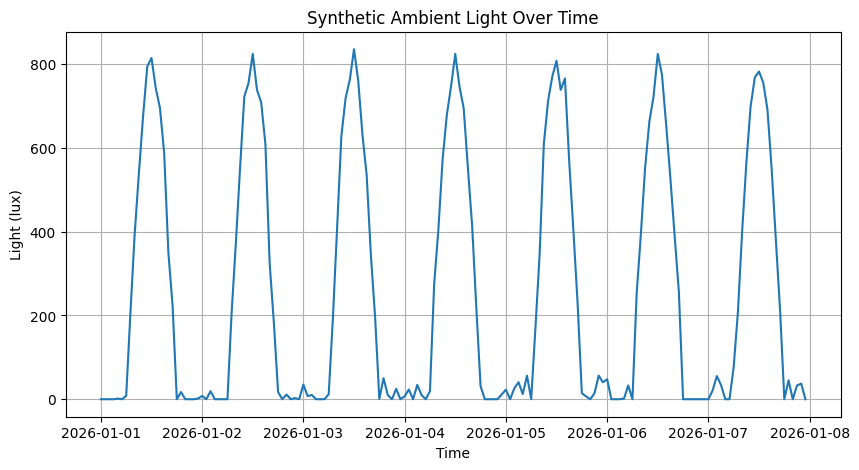

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(weather_df["timestamp"], weather_df["light_lux"])
plt.title("Synthetic Ambient Light Over Time")
plt.xlabel("Time")
plt.ylabel("Light (lux)")
plt.grid(True)
plt.show()

### 8.5 Combined sensor overview

This plot gives a quick overview of all variables. Since the variables have different scales, this visualization is useful for a first inspection but not ideal for detailed comparison.

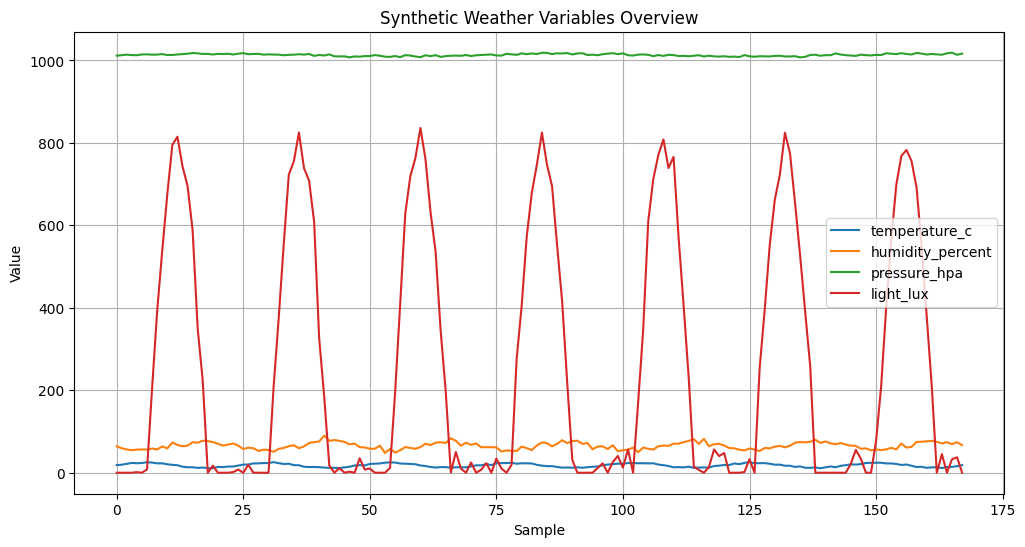

In [32]:
weather_df[
    ["temperature_c", "humidity_percent", "pressure_hpa", "light_lux"]
].plot(figsize=(12, 6))

plt.title("Synthetic Weather Variables Overview")
plt.xlabel("Sample")
plt.ylabel("Value")
plt.grid(True)
plt.show()

## 9. Technical conclusions

From this synthetic dataset analysis, we can conclude that:

- The dataset contains 7 days of hourly simulated weather station data.
- Temperature follows a clear daily cycle, which is realistic for environmental monitoring.
- Humidity shows an inverse relationship with temperature: when temperature increases, humidity tends to decrease.
- Atmospheric pressure changes more slowly and with smaller variations compared to the other variables.
- Ambient light follows a day-night pattern, with values close to zero during night hours.
- The dataset is suitable for practicing data cleaning, visualization, anomaly detection and future Machine Learning experiments.

This notebook represents the first step toward building a complete AI-oriented sensor data analysis pipeline.

## 10. Next steps

The next improvements for this project are:

1. Add missing values and clean them using pandas.
2. Add artificial sensor anomalies and detect them.
3. Export visualizations to the `figures/` folder.
4. Move reusable code into Python scripts inside the `src/` folder.
5. Update the project `README.md` with results and screenshots.
6. Prepare the dataset for a first Machine Learning model using scikit-learn.